# Root Finding with Gaussian Mixture Models

Finding roots of the Peng-Robinson equation of state using GMM conditional sampling.

**Problem:** Find compressibility factors Z where the PR-EOS cubic equals zero.

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 09:59:21
Initial memory usage: 317.98 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

<a id='real-roots'></a>
### 2.1 Real Roots - Peng-Robinson Equation of State

The Peng-Robinson equation of state (PR-EOS) is widely used in chemical engineering for vapor-liquid equilibrium calculations. In its compressibility factor form, it is a cubic equation:

$$Z^3 - (1-B)Z^2 + (A-3B^2-2B)Z - (AB-B^2-B^3) = 0$$

Where:
- $A = \frac{aP}{R^2T^2}$, $B = \frac{bP}{RT}$
- $a = 0.45724 \frac{R^2T_c^2}{P_c} \alpha(T)$, $b = 0.07780 \frac{RT_c}{P_c}$
- $\alpha(T) = [1 + \kappa(1-\sqrt{T/T_c})]^2$
- $\kappa = 0.37464 + 1.54226\omega - 0.26992\omega^2$

In the two-phase region, this cubic equation has **three real roots**: the liquid compressibility ($Z_L$), an unstable intermediate root, and the vapor compressibility ($Z_V$).

We demonstrate root finding using propane at T=300 K and P=10 bar.

In [3]:
# Peng-Robinson EOS for propane
# Critical properties (NIST)
Tc = 369.83  # K - Critical temperature
Pc = 42.48e5  # Pa (42.48 bar) - Critical pressure
omega = 0.1523  # Acentric factor
R = 8.314  # J/(mol*K) - Gas constant

# PR-EOS parameters
kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2

def pr_eos_coefficients(T, P):
    """Calculate A, B and cubic coefficients for PR-EOS."""
    Tr = T / Tc
    alpha = (1 + kappa * (1 - np.sqrt(Tr)))**2
    
    a = 0.45724 * R**2 * Tc**2 / Pc * alpha
    b = 0.07780 * R * Tc / Pc
    
    A = a * P / (R**2 * T**2)
    B = b * P / (R * T)
    
    # Cubic: Z^3 + c2*Z^2 + c1*Z + c0 = 0
    c2 = -(1 - B)
    c1 = A - 3*B**2 - 2*B
    c0 = -(A*B - B**2 - B**3)
    
    return A, B, [1, c2, c1, c0]

def pr_eos_residual(Z, A, B):
    """Residual of PR-EOS cubic equation (should equal zero at roots)."""
    return Z**3 - (1-B)*Z**2 + (A - 3*B**2 - 2*B)*Z - (A*B - B**2 - B**3)

# Conditions: T=300 K, P=10 bar (two-phase region for propane)
T, P = 300, 10e5
A, B, coeffs = pr_eos_coefficients(T, P)

# Analytical roots
roots = np.roots(coeffs)
real_roots = np.sort(roots[np.abs(roots.imag) < 1e-10].real)

print(f"Propane at T={T} K, P={P/1e5:.1f} bar")
print(f"A = {A:.6f}, B = {B:.6f}")
print(f"\nAll roots: {roots}")
print(f"\nReal roots (Z values):")
print(f"  Z_liquid   = {real_roots[0]:.6f}")
print(f"  Z_unstable = {real_roots[1]:.6f}")
print(f"  Z_vapor    = {real_roots[2]:.6f}")

Propane at T=300 K, P=10.0 bar
A = 0.183771, B = 0.022578

All roots: [0.81460369 0.1280356  0.0347832 ]

Real roots (Z values):
  Z_liquid   = 0.034783
  Z_unstable = 0.128036
  Z_vapor    = 0.814604


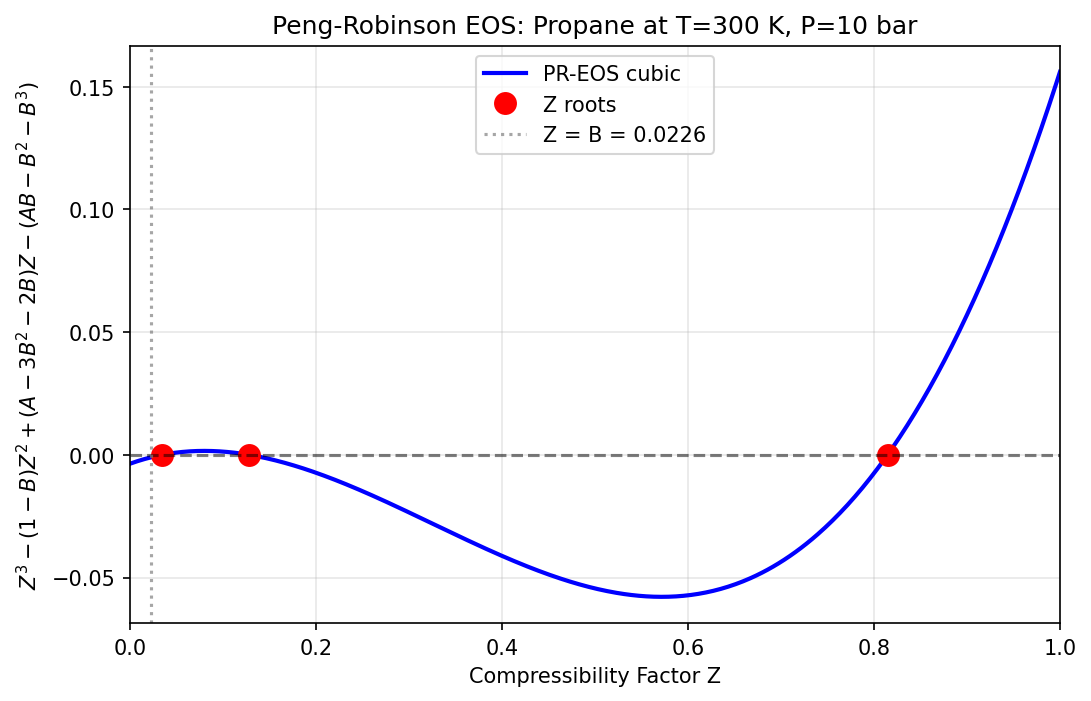

In [4]:
# Visualize the PR-EOS cubic and its roots
Z = np.linspace(0, 1, 500)
y = pr_eos_residual(Z, A, B)

plt.figure(figsize=(8, 5))
plt.plot(Z, y, 'b-', lw=2, label='PR-EOS cubic')
plt.plot(real_roots, [0, 0, 0], 'ro', ms=10, label='Z roots')
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.axvline(B, color='gray', ls=':', alpha=0.7, label=f'Z = B = {B:.4f}')
plt.xlabel('Compressibility Factor Z')
plt.ylabel('$Z^3 - (1-B)Z^2 + (A-3B^2-2B)Z - (AB-B^2-B^3)$')
plt.legend()
plt.title(f'Peng-Robinson EOS: Propane at T={T} K, P={P/1e5:.0f} bar')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show()

In [5]:
# Build generative model for root finding
# Sample Z values and compute the cubic residual
Z_samples = np.linspace(0.01, 0.99, 300)
y_samples = pr_eos_residual(Z_samples, A, B)

data = np.array([Z_samples, y_samples]).T

gmm, info = best_gmm(data, verbose=True)
print(f"\nBest model: {info['best_k']} components")

k=1: BIC=-930.4 *
k=2: BIC=-1978.0 *


k=3: BIC=-2255.4 *
k=4: BIC=-2564.0 *
k=5: BIC=-2770.3 *
k=6: BIC=-2892.0 *
k=7: BIC=-2939.5 *
k=8: BIC=-3014.4 *
k=9: BIC=-3037.2 *
k=10: BIC=-3034.7
k=11: BIC=-3026.3
k=12: BIC=-3020.2
k=13: BIC=-3007.2
k=14: BIC=-2994.7
k=15: BIC=-2968.6


k=16: BIC=-2947.6
k=17: BIC=-2921.2
k=18: BIC=-2900.0


k=19: BIC=-2872.4
Early stopping at k=19

Best model: 9 components


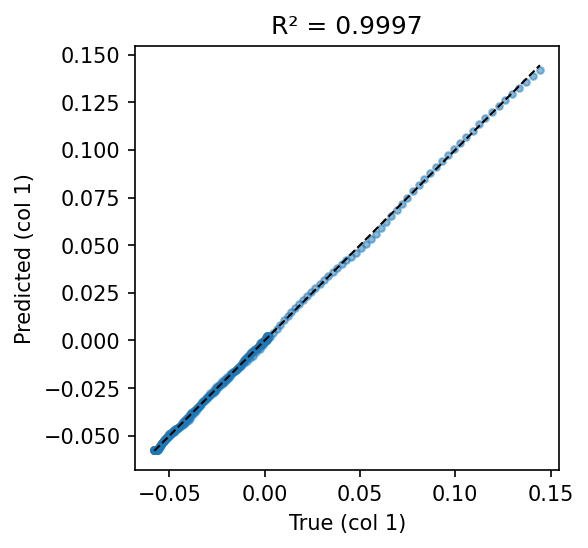


R² = 0.9997
MAE = 0.000559


In [6]:
# Validate the model fit
metrics = validate_gmm(gmm, data, input_cols=[0], output_cols=[1])
print(f"\nR² = {metrics['col_1']['R2']:.4f}")
print(f"MAE = {metrics['col_1']['MAE']:.6f}")

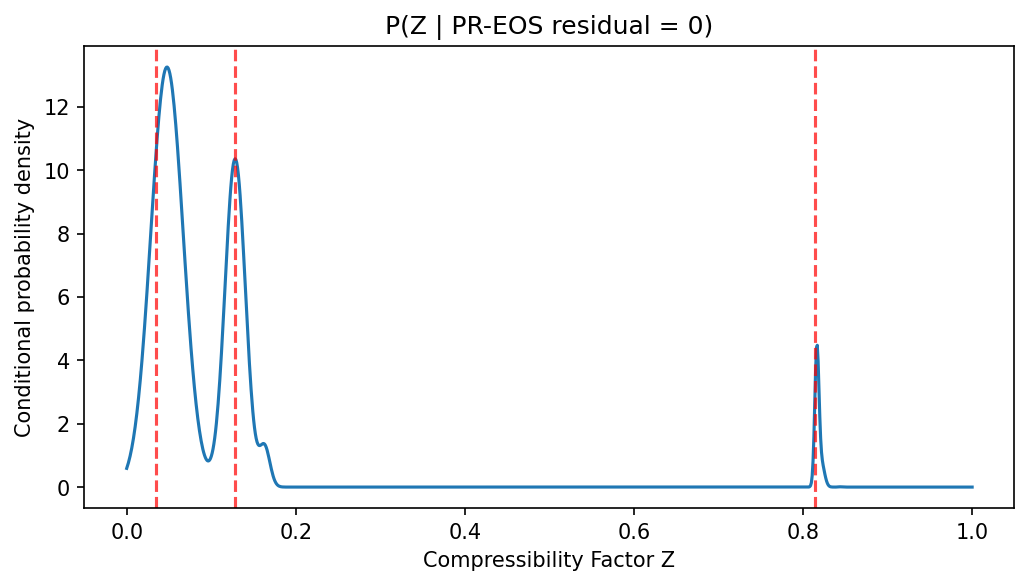

In [7]:
# Compute conditional probability density for residual = 0
c = gmm.condition([1], [[0.0]])  # condition on cubic = 0

_Z = np.linspace(0, 1, 1000)[:, None]

plt.figure(figsize=(8, 4))
plt.plot(_Z, c.to_probability_density(_Z))
for root in real_roots:
    plt.axvline(root, color='r', ls='--', alpha=0.7)
plt.xlabel('Compressibility Factor Z')
plt.ylabel('Conditional probability density')
plt.title('P(Z | PR-EOS residual = 0)')
plt.show()

In [8]:
# Sample the conditional distribution to find Z roots
print("Compressibility factors found by sampling (residual=0):")
cluster_stats(c.sample(1000))

print(f"\nAnalytical solutions:")
print(f"  Z_liquid   = {real_roots[0]:.4f}")
print(f"  Z_unstable = {real_roots[1]:.4f}")
print(f"  Z_vapor    = {real_roots[2]:.4f}")

Compressibility factors found by sampling (residual=0):
  0:   0.8173 +/- 0.0039 (n=31)
  1:   0.0752 +/- 0.0424 (n=969)

Analytical solutions:
  Z_liquid   = 0.0348
  Z_unstable = 0.1280
  Z_vapor    = 0.8146


In [9]:
# Verify the samples - check which ones are actually roots
samples = c.sample(1000)
residual_at_samples = pr_eos_residual(samples[:, 0], A, B)

print("Verification: PR-EOS residual at sampled roots:")
print(f"  Mean |residual|: {np.mean(np.abs(residual_at_samples)):.6f}")
print(f"  Max |residual|:  {np.max(np.abs(residual_at_samples)):.6f}")

# Filter to valid roots
tol = 0.01
valid_roots_samples = samples[np.abs(residual_at_samples) < tol, 0]
print(f"\nAfter filtering (|residual| < {tol}): {len(valid_roots_samples)} samples")
print("Valid Z root clusters:")
cluster_stats(valid_roots_samples)

# Physical interpretation
print("\nPhysical interpretation:")
print("  Smallest Z: Liquid phase (dense, low compressibility)")
print("  Middle Z:   Unstable (spinodal region, thermodynamically unfavorable)")
print("  Largest Z:  Vapor phase (compressible, near ideal gas)")

Verification: PR-EOS residual at sampled roots:
  Mean |residual|: 0.000931
  Max |residual|:  0.006054

After filtering (|residual| < 0.01): 1000 samples
Valid Z root clusters:
  0:   0.8177 +/- 0.0034 (n=37)
  1:   0.0768 +/- 0.0427 (n=963)

Physical interpretation:
  Smallest Z: Liquid phase (dense, low compressibility)
  Middle Z:   Unstable (spinodal region, thermodynamically unfavorable)
  Largest Z:  Vapor phase (compressible, near ideal gas)


In [10]:
# We can also condition on other residual values
# For example, find Z where the cubic equals a small non-zero value
c2 = gmm.condition([1], [[0.001]])
print("Values of Z where PR-EOS cubic residual = 0.001:")
cluster_stats(c2.sample(1000))

Values of Z where PR-EOS cubic residual = 0.001:
  0:   0.8197 +/- 0.0051 (n=42)
  1:   0.0751 +/- 0.0327 (n=958)


In [11]:
# The GMM can also work in the forward direction
# Given Z, predict the cubic residual
test_Z = np.array([[real_roots[0]], [real_roots[1]], [real_roots[2]], [0.5]])
pred_residual = gmm.predict([0], test_Z)

print("Forward prediction (Z -> residual):")
print(f"  Z={real_roots[0]:.4f} (liquid)   -> residual={pred_residual[0, 0]: .6f} (expected: ~0)")
print(f"  Z={real_roots[1]:.4f} (unstable) -> residual={pred_residual[1, 0]: .6f} (expected: ~0)")
print(f"  Z={real_roots[2]:.4f} (vapor)    -> residual={pred_residual[2, 0]: .6f} (expected: ~0)")
print(f"  Z=0.5000 (non-root)   -> residual={pred_residual[3, 0]: .6f} (expected: non-zero)")

Forward prediction (Z -> residual):
  Z=0.0348 (liquid)   -> residual=-0.000252 (expected: ~0)
  Z=0.1280 (unstable) -> residual=-0.000034 (expected: ~0)
  Z=0.8146 (vapor)    -> residual=-0.001464 (expected: ~0)
  Z=0.5000 (non-root)   -> residual=-0.054601 (expected: non-zero)


In [12]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 09:59:21
End time:        2025-12-18 09:59:22
Elapsed time:    1.23 seconds (0.02 minutes)
----------------------------------------------------------------------
Initial memory:  317.98 MB
Final memory:    425.00 MB
Memory change:   +107.02 MB
